# **Deep Learning for Natural Language Processing - AIL7390**
## **Assignment - 1**

**Name:** Irwindeep Singh\
**Roll No.:** B22AI022

## **Dataset Upload**

In [ ]:
from google.colab.files import upload_file
upload_file("dataset.zip")

!unzip -q dataset.zip

Saved dataset.zip to /content/dataset.zip


## **Necessary Imports**

In [ ]:
%pip install -q torchinfo

In [ ]:
import os
from typing import List, Literal, Tuple

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from sklearn.manifold import TSNE
from torch.utils.data import DataLoader, Dataset
from torchinfo import summary
from tqdm.auto import tqdm
from transformers import XLMRobertaConfig, XLMRobertaModel, XLMRobertaTokenizer, logging

logging.set_verbosity_error()
logging.disable_progress_bar()

plt.rcParams["font.family"] = "STIXGeneral"
RANDOM_SEED = 0xDEADBEEF
torch.manual_seed(RANDOM_SEED)

# XLM RoBERTa to be used for multilingual tokenization and pretrained base
XLM_RoBERTa = "xlm-roberta-base"
BATCH_SIZE = 24
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

tokenizer = XLMRobertaTokenizer.from_pretrained(XLM_RoBERTa)

## **Dataset and DataLoader**

In [ ]:
class SanskritEnglishDatset(Dataset):
    def __init__(
        self,
        root: str,
        split: Literal["train", "test", "dev"],
        sanskrit_label: str = "sa",
        english_label: str = "en",
    ) -> None:
        super().__init__()

        sanskrit_csv = os.path.join(root, f"{split}_{sanskrit_label}.csv")
        english_csv = os.path.join(root, f"{split}_{english_label}.csv")

        sanskrit_df = pd.read_csv(sanskrit_csv)
        english_df = pd.read_csv(english_csv)

        if len(sanskrit_df) != len(english_df):
            raise RuntimeError(
                f"Files {sanskrit_csv} and {english_csv} contain different"
                "counts of sentences and cannot be uniquely mapped"
            )

        self.df = sanskrit_df[["Source_id", "Sentence_sa"]].merge(
            english_df[["Source_id", "Sentence_en"]],
            on="Source_id",
            how="inner",
            validate="one_to_one",
        )

    def __len__(self) -> int:
        return len(self.df)

    def __getitem__(self, index: int) -> Tuple[str, str]:
        row = self.df.loc[index]
        sanskrit, english = str(row["Sentence_sa"]), str(row["Sentence_en"])

        return sanskrit, english

In [ ]:
train_dataset = SanskritEnglishDatset(root="dataset", split="train")
val_dataset = SanskritEnglishDatset(root="dataset", split="dev")
test_dataset = SanskritEnglishDatset(root="dataset", split="test")

print(" Dataset Config ".center(50, "-"))
print(f"{'Train Samples':>25}: {len(train_dataset):,}")
print(f"{'Validation Samples':>25}: {len(val_dataset):,}")
print(f"{'Test Samples':>25}: {len(test_dataset):,}")
print("".center(50, "-"))

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

print(" DataLoader Config ".center(50, "-"))
print(f"{'Train Batches':>25}: {len(train_loader):,}")
print(f"{'Validation Batches':>25}: {len(val_loader):,}")
print(f"{'Test Batches':>25}: {len(test_loader):,}")
print("".center(50, "-"))

----------------- Dataset Config -----------------
            Train Samples: 10,000
       Validation Samples: 1,000
             Test Samples: 1,000
--------------------------------------------------
--------------- DataLoader Config ----------------
            Train Batches: 417
       Validation Batches: 42
             Test Batches: 42
--------------------------------------------------


In [ ]:
indices = torch.randint(low=0, high=len(test_dataset) - 1, size=(6,))

print("Example Pairs:\n")
for i, idx in enumerate(indices, start=1):
    sa, en = test_dataset[int(idx)]
    print(f"{i}. SA: {sa}")
    print(f"   EN: {en}")

Example Pairs:

1. SA: अधुना टङ्कयतु "$ ls space -l space example1 " ,Enter  नुदतु च
   EN: Now type:  ls space -l space example1  and press Enter.
2. SA: अधः स्क्रोल् कृत्वा पृष्टस्याधः Save and display गण्डं नुदन्तु ।
   EN: Scroll down and click on Save and display button at the bottom of the page.
3. SA: तौ पुस्तकं द्रक्ष्यतः ।
   EN: They both are looking at the book.
4. SA: "भोजने समाप्ते सति यीशुः शिमोन्पितरं पृष्टवान्, हे यूनसः पुत्र शिमोन् त्वं किम् एतेभ्योधिकं मयि प्रीयसे? ततः स उदितवान् सत्यं प्रभो त्वयि प्रीयेऽहं तद् भवान् जानाति; तदा यीशुरकथयत् तर्हि मम मेषशावकगणं पालय।"
   EN: "So when they had dined, Jesus saith to Simon Peter, Simon, son of Jonas, lovest thou me more than these? He saith unto him, Yea, Lord; thou knowest that I love thee. He saith unto him, Feed my lambs."
5. SA: बालकौ कथां श्रुतवन्तौ ।
   EN: Boys heard story.
6. SA: ईश्वरं प्रति यीशुख्रीष्टेन मम श्लाघाकरणस्य कारणम् आस्ते।
   EN: I have therefore whereof I may glory through Jesus Christ in those things

## **Sentence Embeddings Model**

In [ ]:
class SentenceEncoder(nn.Module):
    def __init__(
        self,
        embedding_dim: int = 256,
        pretrained: bool = True,
        freeze_encoder: bool = False,
    ) -> None:
        super(SentenceEncoder, self).__init__()

        encoder_config = XLMRobertaConfig.from_pretrained(XLM_RoBERTa)
        if pretrained:
            self.encoder = XLMRobertaModel.from_pretrained(
                XLM_RoBERTa,
                add_pooling_layer=False,
            )
        else:
            self.encoder = XLMRobertaModel(encoder_config, add_pooling_layer=False)

        if freeze_encoder:
            for param in self.encoder.parameters():
                param.requires_grad = False

        self.pooler = nn.Linear(encoder_config.hidden_size, embedding_dim)

    def forward(self, input_ids, attention_mask) -> torch.Tensor:
        tokens = input_ids
        mask = attention_mask.unsqueeze(-1)

        output = self.encoder(tokens).last_hidden_state
        output = (output * mask).sum(dim=1) / mask.sum(dim=1)
        output = self.pooler(output)

        return output

In [ ]:
def sentence_embedding(model: SentenceEncoder, texts: str | List[str]) -> torch.Tensor:
    tokenizer_op = tokenizer(
        texts,
        return_tensors="pt",
        padding=True,
        truncation=True,
    ).to(DEVICE)

    input_ids, attention_mask = tokenizer_op.input_ids, tokenizer_op.attention_mask
    output = model(input_ids, attention_mask)

    return output


sa_encoder = SentenceEncoder().to(DEVICE)
en_encoder = SentenceEncoder().to(DEVICE)

tokenizer_op = tokenizer(
    "Deep Learning for Natural Language Processing",
    return_tensors="pt",
    padding=True,
    truncation=True,
).to(DEVICE)

input_ids, attention_mask = tokenizer_op.input_ids, tokenizer_op.attention_mask
summary(sa_encoder, input_data=(input_ids, attention_mask))

Layer (type:depth-idx)                                       Output Shape              Param #
SentenceEncoder                                              [1, 256]                  --
├─XLMRobertaModel: 1-1                                       [1, 9, 768]               --
│    └─XLMRobertaEmbeddings: 2-1                             [1, 9, 768]               --
│    │    └─Embedding: 3-1                                   [1, 9, 768]               192,001,536
│    │    └─Embedding: 3-2                                   [1, 9, 768]               768
│    │    └─Embedding: 3-3                                   [1, 9, 768]               394,752
│    │    └─LayerNorm: 3-4                                   [1, 9, 768]               1,536
│    │    └─Dropout: 3-5                                     [1, 9, 768]               --
│    └─XLMRobertaEncoder: 2-2                                [1, 9, 768]               --
│    │    └─ModuleList: 3-6                                  --              

## **Contrastive Learning Symmetric Cross Entropy Loss**

In [ ]:
class ContrastiveLoss(nn.Module):
    def __init__(self, temp: float = 0.07) -> None:
        super(ContrastiveLoss, self).__init__()

        self.normalize = lambda x: x / torch.norm(x, p=2, dim=-1, keepdim=True)
        self.ce_loss_fn = nn.CrossEntropyLoss()

        self.log_temp = nn.Parameter(torch.tensor(np.log(temp), device=DEVICE))

    def forward(
        self, sa_embedding: torch.Tensor, en_embedding: torch.Tensor
    ) -> torch.Tensor:
        N = sa_embedding.size(0)
        sa_emb = self.normalize(sa_embedding)
        en_emb = self.normalize(en_embedding)

        temp = torch.clamp(torch.exp(self.log_temp), 0.01, 0.2)
        logits = (sa_emb @ en_emb.T) / temp

        labels = torch.arange(N, device=sa_emb.device)
        loss_sa = self.ce_loss_fn(logits, labels)
        loss_en = self.ce_loss_fn(logits.T, labels)

        return (loss_sa + loss_en) / 2

## **Training Models**

In [ ]:
epochs = 5
loss_fn = ContrastiveLoss()
optim = torch.optim.AdamW(
    [
        {"params": sa_encoder.encoder.parameters(), "lr": 1e-5},
        {"params": en_encoder.encoder.parameters(), "lr": 1e-5},
        {"params": sa_encoder.pooler.parameters(), "lr": 1e-3},
        {"params": en_encoder.pooler.parameters(), "lr": 1e-3},
        {"params": loss_fn.parameters(), "lr": 1e-5},
    ]
)
scaler = torch.amp.grad_scaler.GradScaler(DEVICE)

In [ ]:
@torch.no_grad()
def val_epoch(pbar: tqdm, train_loss: float) -> float:
    sa_encoder.eval()
    en_encoder.eval()

    num_batches = len(val_loader)
    val_loss = 0.0

    for batch, (sa, en) in enumerate(val_loader, start=1):
        with torch.amp.autocast_mode.autocast(DEVICE):
            sa_emb = sentence_embedding(sa_encoder, sa)
            en_emb = sentence_embedding(en_encoder, en)

            loss = loss_fn(sa_emb, en_emb)

        val_loss += loss.item()
        pbar.set_postfix(
            {
                "Train Loss": f"{train_loss:.4f}",
                "Val Loss": f"{val_loss / batch:.4f}",
            }
        )

    return val_loss / num_batches


def train_epoch(desc: str) -> Tuple[float, float]:
    sa_encoder.train()
    en_encoder.train()

    num_batches = len(train_loader)
    train_loss = 0.0

    pbar = tqdm(total=num_batches, desc=desc)
    for batch, (sa, en) in enumerate(train_loader, start=1):
        optim.zero_grad()

        with torch.amp.autocast_mode.autocast(DEVICE):
            sa_emb = sentence_embedding(sa_encoder, sa)
            en_emb = sentence_embedding(en_encoder, en)

            loss = loss_fn(sa_emb, en_emb)

        scaler.scale(loss).backward()
        scaler.step(optim)
        scaler.update()

        train_loss += loss.item()
        pbar.set_postfix(
            {
                "Train Loss": f"{train_loss / batch:.4f}",
                "Val Loss": "-",
            }
        )
        pbar.update(1)

    train_loss /= num_batches
    val_loss = val_epoch(pbar, train_loss)
    pbar.close()

    return train_loss, val_loss

In [ ]:
train_losses, val_losses = [], []
for epoch in range(1, epochs + 1):
    desc = f"Epoch[{epoch}/{epochs}]"
    train_loss, val_loss = train_epoch(desc)

    train_losses.append(train_loss)
    val_losses.append(val_loss)

Epoch[1/5]:   0%|          | 0/417 [00:00<?, ?it/s]

Epoch[2/5]:   0%|          | 0/417 [00:00<?, ?it/s]

Epoch[3/5]:   0%|          | 0/417 [00:00<?, ?it/s]

Epoch[4/5]:   0%|          | 0/417 [00:00<?, ?it/s]

Epoch[5/5]:   0%|          | 0/417 [00:00<?, ?it/s]

## **Visualizations**

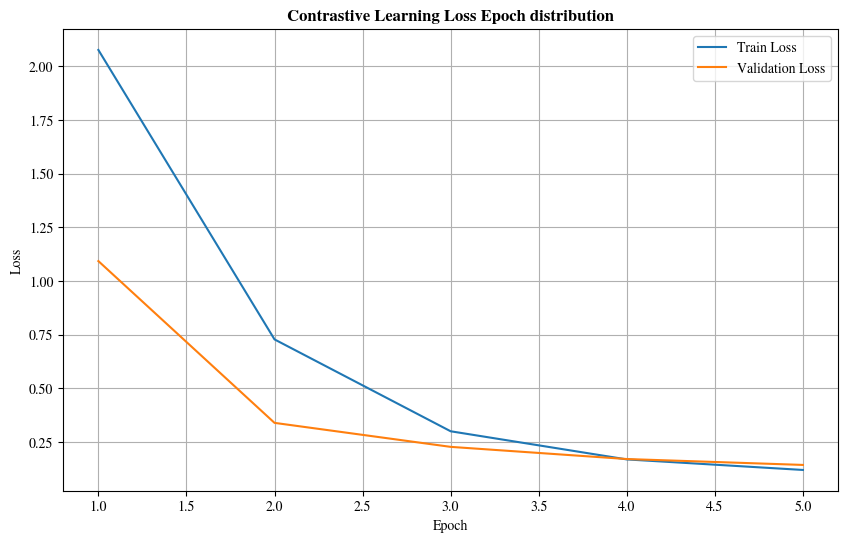

In [ ]:
os.makedirs("figures", exist_ok=True)

plt.figure(figsize=(10, 6))
plt.plot(range(1, epochs + 1), train_losses, label="Train Loss")
plt.plot(range(1, epochs + 1), val_losses, label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Contrastive Learning Loss Epoch distribution", fontweight="bold")
plt.grid()
plt.legend()
plt.savefig("figures/loss_epoch.svg")

In [ ]:
tsne = TSNE(n_components=2)

sa_embeddings, en_embeddings = [], []
with torch.no_grad():
    for i in tqdm(range(100), desc="TSNE Embeddings"):
        sa, en = train_dataset[i]
        sa_emb = sentence_embedding(sa_encoder, sa).squeeze().cpu().numpy()
        en_emb = sentence_embedding(en_encoder, en).squeeze().cpu().numpy()

        sa_emb = sa_emb / np.linalg.norm(sa_emb)
        en_emb = en_emb / np.linalg.norm(en_emb)

        sa_embeddings.append(sa_emb)
        en_embeddings.append(en_emb)

sa_embeddings = np.stack(sa_embeddings)
en_embeddings = np.stack(en_embeddings)

sa_tsne = tsne.fit_transform(sa_embeddings)
en_tsne = tsne.fit_transform(en_embeddings)

TSNE Embeddings:   0%|          | 0/100 [00:00<?, ?it/s]

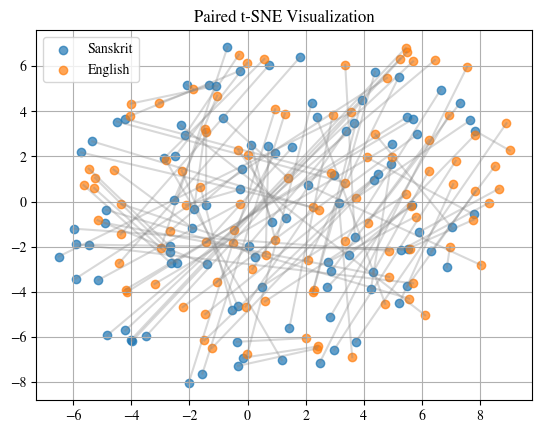

In [ ]:
plt.scatter(sa_tsne[:, 0], sa_tsne[:, 1], label='Sanskrit', alpha=0.7)
plt.scatter(en_tsne[:, 0], en_tsne[:, 1], label='English', alpha=0.7)

for i in range(len(sa_tsne)):
    plt.plot(
        [sa_tsne[i, 0], en_tsne[i, 0]],
        [sa_tsne[i, 1], en_tsne[i, 1]],
        'gray',
        alpha=0.3
    )

plt.grid()
plt.legend()
plt.title("Paired t-SNE Visualization")
plt.savefig("tsne.svg")

In [ ]:
import pickle

with open("sa_encoder.pkl", "wb") as file:
    pickle.dump(sa_encoder, file)

with open("en_encoder.pkl", "wb") as file:
    pickle.dump(en_encoder, file)

## **Inference and Evaluation**

In [1]:
from google.colab import files

files.upload_file("test_sa.csv")
files.upload_file("test_en.csv")

Saved test_demo_sa - Sheet1.csv to /content/test_sa.csv


Saved test_demo_en - Sheet1.csv to /content/test_en.csv


In [2]:
from typing import List

import torch
import torch.nn as nn
import matplotlib.pyplot as plt
from sklearn.manifold import TSNE
from transformers import XLMRobertaConfig, XLMRobertaModel, XLMRobertaTokenizer, logging

logging.set_verbosity_error()
logging.disable_progress_bar()

plt.rcParams["font.family"] = "STIXGeneral"
RANDOM_SEED = 0xDEADBEEF
torch.manual_seed(RANDOM_SEED)

# XLM RoBERTa to be used for multilingual tokenization and pretrained base
XLM_RoBERTa = "xlm-roberta-base"
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

tokenizer = XLMRobertaTokenizer.from_pretrained(XLM_RoBERTa)

class SentenceEncoder(nn.Module):
    def __init__(
        self,
        embedding_dim: int = 256,
        pretrained: bool = True,
        freeze_encoder: bool = False,
    ) -> None:
        super(SentenceEncoder, self).__init__()

        encoder_config = XLMRobertaConfig.from_pretrained(XLM_RoBERTa)
        if pretrained:
            self.encoder = XLMRobertaModel.from_pretrained(
                XLM_RoBERTa,
                add_pooling_layer=False,
            )
        else:
            self.encoder = XLMRobertaModel(encoder_config, add_pooling_layer=False)

        if freeze_encoder:
            for param in self.encoder.parameters():
                param.requires_grad = False

        self.pooler = nn.Linear(encoder_config.hidden_size, embedding_dim)

    def forward(self, input_ids, attention_mask) -> torch.Tensor:
        tokens = input_ids
        mask = attention_mask.unsqueeze(-1)

        output = self.encoder(tokens).last_hidden_state
        output = (output * mask).sum(dim=1) / mask.sum(dim=1)
        output = self.pooler(output)

        return output

def sentence_embedding(model: SentenceEncoder, texts: str | List[str]) -> torch.Tensor:
    tokenizer_op = tokenizer(
        texts,
        return_tensors="pt",
        padding=True,
        truncation=True,
    ).to(DEVICE)

    input_ids, attention_mask = tokenizer_op.input_ids, tokenizer_op.attention_mask
    output = model(input_ids, attention_mask)

    return output

In [3]:
import pandas as pd
import numpy as np
import pickle
import gdown
from tqdm.auto import tqdm

SA_ENCODER_ID = "1Eh-BmwILVfSrYMK98jmqksy16Xl3-vdT"
EN_ENCODER_ID = "178A-OQOcC3bPOHnuIV0rAk1JsokzpTIj"

sa_encoder_file = "sa_encoder.pkl"
en_encoder_file = "en_encoder.pkl"

gdown.download(id=SA_ENCODER_ID, output=sa_encoder_file)
gdown.download(id=EN_ENCODER_ID, output=en_encoder_file)

with open(sa_encoder_file, "rb") as file:
    sa_encoder = pickle.load(file).to(DEVICE)

with open(en_encoder_file, "rb") as file:
    en_encoder = pickle.load(file).to(DEVICE)

sa_texts = pd.read_csv("test_sa.csv")["Sentence_sa"]
en_texts = pd.read_csv("test_en.csv")["Sentence_en"]

Downloading...
From (original): https://drive.google.com/uc?id=1Eh-BmwILVfSrYMK98jmqksy16Xl3-vdT
From (redirected): https://drive.google.com/uc?id=1Eh-BmwILVfSrYMK98jmqksy16Xl3-vdT&confirm=t&uuid=002e97b6-c27f-4c93-8700-824bf5922313
To: /content/sa_encoder.pkl
100%|██████████| 1.11G/1.11G [00:15<00:00, 73.7MB/s]
Downloading...
From (original): https://drive.google.com/uc?id=178A-OQOcC3bPOHnuIV0rAk1JsokzpTIj
From (redirected): https://drive.google.com/uc?id=178A-OQOcC3bPOHnuIV0rAk1JsokzpTIj&confirm=t&uuid=2756eb2b-8af6-4e99-9ada-bbb4595b802e
To: /content/en_encoder.pkl
100%|██████████| 1.11G/1.11G [00:24<00:00, 45.5MB/s]


In [4]:
sa_embeddings = []
en_embeddings = []

cosine_sim = 0.0
with torch.no_grad():
    bar = tqdm(total=len(sa_texts), desc="Evaluating Embeddings")
    for i, (sa, en) in enumerate(zip(sa_texts, en_texts)):
        sa_emb = sentence_embedding(sa_encoder, sa).squeeze()
        en_emb = sentence_embedding(en_encoder, en).squeeze()

        sa_emb = sa_emb / torch.norm(sa_emb)
        en_emb = en_emb / torch.norm(en_emb)

        sa_embeddings.append(sa_emb.cpu().numpy())
        en_embeddings.append(en_emb.cpu().numpy())

        sim = torch.dot(sa_emb, en_emb)
        cosine_sim += sim.item()
        bar.set_postfix({"Similarity": f"{cosine_sim / (i+1):.4f}"})
        bar.update(1)
    bar.close()

cosine_sim /= len(sa_texts)
print(f"Cosine Similarity: {cosine_sim:.4f}")
print(
    f"Interpretation: An average angle of {np.degrees(np.arccos(cosine_sim)):.2f} degrees is there in Sanskrit and English Embeddings"
)

Evaluating Embeddings:   0%|          | 0/100 [00:00<?, ?it/s]

Cosine Similarity: 0.7296
Interpretation: An average angle of 43.15 degrees is there in Sanskrit and English Embeddings


In [5]:
sa_embeddings = np.stack(sa_embeddings)
en_embeddings = np.stack(en_embeddings)

print(sa_embeddings.shape)
print(en_embeddings.shape)

(100, 256)
(100, 256)


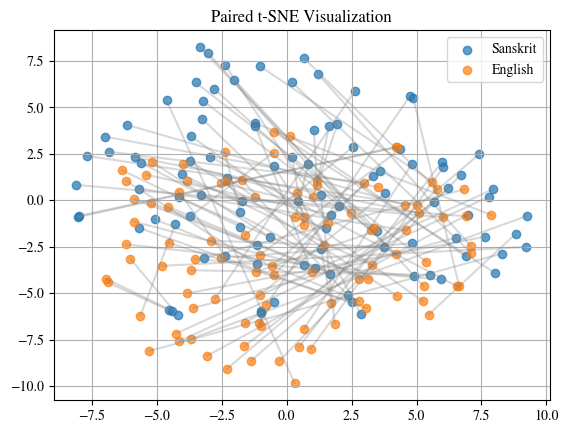

In [6]:
tsne = TSNE(2)
sa_tsne = tsne.fit_transform(sa_embeddings[:100])
en_tsne = tsne.fit_transform(en_embeddings[:100])

plt.scatter(sa_tsne[:, 0], sa_tsne[:, 1], label='Sanskrit', alpha=0.7)
plt.scatter(en_tsne[:, 0], en_tsne[:, 1], label='English', alpha=0.7)

for i in range(len(sa_tsne)):
    plt.plot(
        [sa_tsne[i, 0], en_tsne[i, 0]],
        [sa_tsne[i, 1], en_tsne[i, 1]],
        'gray',
        alpha=0.3
    )

plt.grid()
plt.legend()
plt.title("Paired t-SNE Visualization")
plt.savefig("tsne.svg")

In [7]:
np.save("sa_embeddings.npy", sa_embeddings)
np.save("en_embeddings.npy", en_embeddings)